In [7]:
import numpy as np 
import matplotlib.pyplot as plt

from build_solver import build_erg_time_opt_solver

import pickle as pkl


# Computation Results

In [9]:
knots = [50, 200, 400, 600, 800, 1000]
knot_results = {
    'avg': [],
    'std': []}
for i, knot in enumerate(knots):
    args = {
        'N' : knot, 
        'x0' : np.array([0.1, 0.1, 0., 0.]),
        'xf' : np.array([0.9, 0.9, 0., 0.]),
        'erg_ub' : 0.1,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
    solver = build_erg_time_opt_solver(init_sol, args)
    _res = %timeit -o solver.solve(max_iter=1, eps=1e-7)
    knot_results['avg'].append(_res.average)
    knot_results['std'].append(_res.stdev)


The slowest run took 6.00 times longer than the fastest. This could mean that an intermediate result is being cached.
271 µs ± 231 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
450 µs ± 233 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
711 µs ± 248 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
1 ms ± 279 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.23 ms ± 316 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.38 ms ± 272 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
knots = [50, 100, 200, 300, 400, 500]
convergence_res = {
    'avg': [],
    'std': []}
for i, knot in enumerate(knots):
    args = {
        'N' : knot, 
        'x0' : np.array([0.1, 0.1, 0., 0.]),
        'xf' : np.array([0.9, 0.9, 0., 0.]),
        'erg_ub' : 0.1,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
    solver = build_erg_time_opt_solver(init_sol, args)
    _res = %timeit -o solver.solve(max_iter=10_000, eps=1e-7)
    convergence_res['avg'].append(_res.average)
    convergence_res['std'].append(_res.stdev)

done in  7875  iterations
1.71 s ± 58.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
done in  6258  iterations
2.63 s ± 39.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
done in  512  iterations
3.85 s ± 55 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
done in  1310  iterations
done in  4611  iterations
The slowest run took 4.56 times longer than the fastest. This could mean that an intermediate result is being cached.
5.53 s ± 2.25 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
done in  5785  iterations
6.16 s ± 102 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
7.31 s ± 100 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [19]:
num_basis = [5, 10, 20, 30, 40]
basis_res = {
    'avg': [],
    'std': []}
for i, _n_basis in enumerate(num_basis):
    args = {
        'N' : 100, 
        'x0' : np.array([0.1, 0.1, 0., 0.]),
        'xf' : np.array([0.9, 0.9, 0., 0.]),
        'erg_ub' : 0.1,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
    solver = build_erg_time_opt_solver(init_sol, args, num_basis=_n_basis)
    solver.solve(max_iter=1, eps=1e-7)
    _res = %timeit -o solver.solve(max_iter=1, eps=1e-7)
    basis_res['avg'].append(_res.average)
    basis_res['std'].append(_res.stdev)

127 µs ± 3 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
292 µs ± 2.8 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
866 µs ± 34.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.69 ms ± 15.7 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
3.36 ms ± 20.6 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


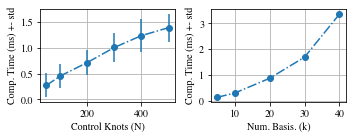

In [21]:
plt.rcParams["font.family"] = "times"

fig, axs = plt.subplots(1, 2, figsize=(5,2))

axs[0].errorbar(knots, np.array(knot_results['avg'])*1e3, yerr=np.array(knot_results['std'])*1e3, fmt='-.o')
axs[0].grid()
axs[0].set_xlabel('Control Knots (N)')
axs[0].set_ylabel('Comp. Time (ms) +- std')


axs[1].errorbar(num_basis, np.array(basis_res['avg'])*1e3, yerr=np.array(basis_res['std'])*1e3, fmt='-.o')
axs[1].grid()
axs[1].set_xlabel('Num. Basis. (k)')
axs[1].set_ylabel('Comp. Time (ms) +- std')

fig.tight_layout()

plt.savefig('additional_comp.pdf')

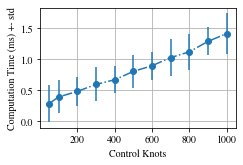

In [23]:
# plt.rcParams["font.family"] = "freeserif"
plt.rcParams["font.family"] = "times"

plt.figure(figsize=(3.5,2.2))
plt.errorbar(knots, np.array(avg_res)*1e3, yerr=np.array(std_res)*1e3, fmt='-.o')
plt.grid()
plt.xlabel('Control Knots')
plt.ylabel('Computation Time (ms) +- std')
# plt.legend()
plt.savefig('comp_anal.pdf')

Text(0, 0.5, 'Computation Time (ms) +- std')

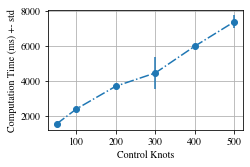

In [28]:
plt.rcParams["font.family"] = "times"

plt.figure(figsize=(3.5,2.2))
plt.errorbar(knots, np.array(avg_res)*1e3, yerr=np.array(std_res)*1e3, fmt='-.o')
plt.grid()
plt.xlabel('Control Knots')
plt.ylabel('Computation Time (ms) +- std')

In [5]:
num_basis = [5, 8, 10, 20, 50, 100]
avg_res = []
std_res = []
for i, _n_basis in enumerate(num_basis):
    args = {
        'N' : 100, 
        'x0' : np.array([0.1, 0.1, 0., 0.]),
        'xf' : np.array([0.9, 0.9, 0., 0.]),
        'erg_ub' : 0.1,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
    solver = build_erg_time_opt_solver(init_sol, args, num_basis=_n_basis)
    solver.solve(max_iter=1, eps=1e-7)
    _res = %timeit -o solver.solve(max_iter=1, eps=1e-7)
    avg_res.append(_res.average)
    std_res.append(_res.stdev)


126 µs ± 1.52 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
219 µs ± 4.52 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
298 µs ± 6.97 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
850 µs ± 13.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.72 ms ± 186 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
10 ms ± 231 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Text(0, 0.5, 'Computation Time (ms) +- std')

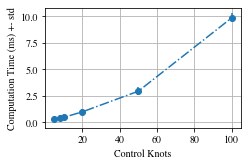

In [4]:
plt.rcParams["font.family"] = "times"

plt.figure(figsize=(3.5,2.2))
plt.errorbar(num_basis, np.array(avg_res)*1e3, yerr=np.array(std_res)*1e3, fmt='-.o')
plt.grid()
plt.xlabel('Control Knots')
plt.ylabel('Computation Time (ms) +- std')

# Scale Result

In [ ]:
knots = [50, 200, 400, 600, 800, 1000]
knot_results = {
    'avg': [],
    'std': []}
for i, knot in enumerate(knots):
    args = {
        'N' : knot, 
        'x0' : np.array([0.1, 0.1, 0., 0.]),
        'xf' : np.array([0.9, 0.9, 0., 0.]),
        'erg_ub' : 0.1,
    }
    x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
    u = np.zeros((args['N'], 2))
    init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
    solver = build_erg_time_opt_solver(init_sol, args)
    _res = %timeit -o solver.solve(max_iter=1, eps=1e-7)
    knot_results['avg'].append(_res.average)
    knot_results['std'].append(_res.stdev)